In [3]:
import pandas as pd
import numpy as np

# 🌍 Fossil Fuel CO₂ Emissions Forecasting Project

## 📖 Introduction: The Story Behind Fossil Emissions

Fossil fuel emissions are the invisible footprint of modern civilization. Every time electricity is generated, fuel is burned in transport, or industries manufacture goods, carbon dioxide is released into the atmosphere. Since 1970, global economic expansion has been closely tied to fossil fuel consumption, creating a long-term environmental impact that is both measurable and predictable.

This project treats CO₂ emissions not just as numbers, but as a **time-evolving system shaped by industrial growth, policy changes, and energy transitions**. Understanding this system allows us to forecast future emissions and support climate decision-making.

---

## 📌 Project Overview

The project focuses on predictive modeling of fossil-based CO₂ emissions using the **SARIMA (Seasonal Autoregressive Integrated Moving Average)** framework. It leverages the EDGAR dataset, which tracks emissions across various countries and economic sectors from 1970 to 2018.

---

## 🔁 Project Workflow and Methodology

The project follows a structured time-series forecasting pipeline:

### 1. Data Ingestion and Structuring
The raw dataset, containing over 9,700 records, is cleaned by:
- Standardizing column names:
  - Country
  - ISO Code
  - Year
  - Sector
- Removing missing and duplicate entries

---

### 2. Preprocessing
Missing emission values are handled using:
- Linear interpolation
- Forward fill and backward fill within each country-sector group

---

### 3. Data Transformation
The dataset is transformed from:
- **Wide format** (years as columns like Y_1970, Y_1971, …)
- to **Long format** (Year → CO₂ Emissions)

It is then aggregated at:
- Country level
- Sector level

---

## 📊 Statistical Analysis and Findings

### 1. Stationarity Testing
Using the Augmented Dickey-Fuller (ADF) test:

- The CO₂ emission series (e.g., Canada) is **non-stationary**
- This indicates the presence of long-term trends
- First-order differencing is required to stabilize the series

---

### 2. Temporal Dependencies
Autocorrelation Function (ACF) analysis shows:

- Strong dependency at lag 1–3
- Gradual decay after lag 3
- Minimal correlation after lag 5

This suggests emissions are:
- strongly short-term dependent
- weakly influenced by distant historical values

---

## 📈 Predictive Modeling Strategy

The project explores three main forecasting approaches:

### 1. Proportional Allocation
Uses historical sector contributions to distribute country-level forecasts.

### 2. Individual Sector Models
Each sector is modeled separately using SARIMA, allowing:
- sector-specific behavior capture
- higher granularity forecasting

### 3. Exogenous Variable Approach (SARIMAX)
Sector emissions are included as external variables in a **SARIMAX model**, improving prediction accuracy by incorporating cross-sector influence.

---

## 🧠 Key Insight

Fossil fuel emissions behave as a **trend-dominated, weakly seasonal time series system**, where:

- Long-term growth reflects industrial expansion
- Short-term fluctuations reflect policy and economic shocks
- Sector behavior adds structural complexity

---

## ⚙️ Modeling Framework

The final forecasting engine is built using:

- SARIMA model for time-series prediction
- Differencing for stationarity
- Train-test split validation
- Error metrics (MAE, RMSE, MAPE)

---

## 🌍 Conclusion

This project demonstrates that fossil fuel emissions are not random but follow structured temporal dynamics. By leveraging SARIMA-based forecasting, we can model historical emissions behavior and project future trends, supporting climate analysis and policy planning.

---

In [11]:
df = pd.read_csv("data.csv", skiprows=9)

In [13]:
print(df.head(6))

  IPCC_annex C_group_IM24_sh Country_code_A3    Name  \
0    Annex_I          Canada             CAN  Canada   
1    Annex_I          Canada             CAN  Canada   
2    Annex_I          Canada             CAN  Canada   
3    Annex_I          Canada             CAN  Canada   
4    Annex_I          Canada             CAN  Canada   
5    Annex_I          Canada             CAN  Canada   

  ipcc_code_2006_for_standard_report  \
0                            1.A.1.a   
1                           1.A.1.bc   
2                              1.A.2   
3                            1.A.3.a   
4                      1.A.3.b_noRES   
5                            1.A.3.c   

             ipcc_code_2006_for_standard_report_name fossil_bio   Y_1970  \
0      Main Activity Electricity and Heat Production     fossil  45100.0   
1  Petroleum Refining - Manufacture of Solid Fuel...     fossil  29000.0   
2          Manufacturing Industries and Construction     fossil  78300.0   
3                     

This dataset represents a multi-dimensional time series of fossil-based CO₂ emissions reported under the Intergovernmental Panel on Climate Change classification framework. It contains country-level emissions data (e.g., Canada identified by ISO code CAN) disaggregated by economic activity sectors defined using the 2006 IPCC reporting codes, such as electricity and heat production, transportation, and manufacturing industries. Key categorical features include IPCC_annex (indicating reporting group), Country_code_A3 and Name (geographical identifiers), and ipcc_code_2006_for_standard_report alongside its descriptive name (sector classification). The variable fossil_bio distinguishes emission origin (e.g., fossil fuels). Temporal features span from 1970 to 2018 (columns Y_1970 to Y_2018), representing annual emission values, typically in tonnes. This structure supports time-series analysis, sectoral emission comparisons, and predictive modeling of future emissions trends based on historical patterns across sectors and years.

In [15]:
print(df.shape)        # rows, columns

print(df.columns)

(9785, 57)
Index(['IPCC_annex', 'C_group_IM24_sh', 'Country_code_A3', 'Name',
       'ipcc_code_2006_for_standard_report',
       'ipcc_code_2006_for_standard_report_name', 'fossil_bio', 'Y_1970',
       'Y_1971', 'Y_1972', 'Y_1973', 'Y_1974', 'Y_1975', 'Y_1976', 'Y_1977',
       'Y_1978', 'Y_1979', 'Y_1980', 'Y_1981', 'Y_1982', 'Y_1983', 'Y_1984',
       'Y_1985', 'Y_1986', 'Y_1987', 'Y_1988', 'Y_1989', 'Y_1990', 'Y_1991',
       'Y_1992', 'Y_1993', 'Y_1994', 'Y_1995', 'Y_1996', 'Y_1997', 'Y_1998',
       'Y_1999', 'Y_2000', 'Y_2001', 'Y_2002', 'Y_2003', 'Y_2004', 'Y_2005',
       'Y_2006', 'Y_2007', 'Y_2008', 'Y_2009', 'Y_2010', 'Y_2011', 'Y_2012',
       'Y_2013', 'Y_2014', 'Y_2015', 'Y_2016', 'Y_2017', 'Y_2018',
       'Unnamed: 56'],
      dtype='object')


In [16]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9785 entries, 0 to 9784
Data columns (total 57 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   IPCC_annex                               3464 non-null   object 
 1   C_group_IM24_sh                          3464 non-null   object 
 2   Country_code_A3                          3464 non-null   object 
 3   Name                                     3464 non-null   object 
 4   ipcc_code_2006_for_standard_report       3464 non-null   object 
 5   ipcc_code_2006_for_standard_report_name  3464 non-null   object 
 6   fossil_bio                               3464 non-null   object 
 7   Y_1970                                   2814 non-null   float64
 8   Y_1971                                   2818 non-null   float64
 9   Y_1972                                   2823 non-null   float64
 10  Y_1973                                   2836 no

In [17]:
missing = df.isnull().sum()
print(missing[missing > 0])

IPCC_annex                                 6321
C_group_IM24_sh                            6321
Country_code_A3                            6321
Name                                       6321
ipcc_code_2006_for_standard_report         6321
ipcc_code_2006_for_standard_report_name    6321
fossil_bio                                 6321
Y_1970                                     6971
Y_1971                                     6967
Y_1972                                     6962
Y_1973                                     6949
Y_1974                                     6911
Y_1975                                     6898
Y_1976                                     6886
Y_1977                                     6896
Y_1978                                     6831
Y_1979                                     6808
Y_1980                                     6773
Y_1981                                     6780
Y_1982                                     6777
Y_1983                                  

In [18]:
df = df.loc[:, ~df.columns.str.contains("^Unnamed")]

In [19]:
print(df.duplicated().sum())
df = df.drop_duplicates()

6320


In [20]:
print(df['IPCC_annex'].unique())
print(df['Name'].unique())
print(df['fossil_bio'].unique())

['Annex_I' 'Non-Annex_I' 'Int. Shipping' 'Int. Aviation' nan]
['Canada' 'Saint Pierre and Miquelon' 'United States' 'Mexico' 'Aruba'
 'Anguilla' 'Netherlands Antilles' 'Antigua and Barbuda' 'Bahamas'
 'Belize' 'Bermuda' 'Barbados' 'Costa Rica' 'Cuba' 'Cayman Islands'
 'Dominica' 'Dominican Republic' 'Guadeloupe' 'Grenada' 'Guatemala'
 'Honduras' 'Haiti' 'Jamaica' 'Saint Kitts and Nevis' 'Saint Lucia'
 'Montserrat' 'Martinique' 'Nicaragua' 'Panama' 'Puerto Rico'
 'El Salvador' 'Turks and Caicos Islands' 'Trinidad and Tobago'
 'Saint Vincent and the Grenadines' 'Virgin Islands_British'
 'Virgin Islands_USA' 'Brazil' 'Argentina' 'Bolivia' 'Chile' 'Colombia'
 'Ecuador' 'Falkland Islands (Malvinas)' 'French Guiana' 'Guyana' 'Peru'
 'Paraguay' 'Suriname' 'Uruguay' 'Venezuela' 'Algeria' 'Egypt'
 'Western Sahara' 'Libyan Arab Jamahiriya' 'Morocco' 'Tunisia' 'Benin'
 'Burkina Faso' 'Central African Republic' "Cote d'Ivoire" 'Cameroon'
 'Congo_the Democratic Republic of the' 'Congo' 'Cape Verde'

In [21]:

# 1. Drop completely empty columns (like Unnamed)
df = df.dropna(axis=1, how='all')



# 3. Drop duplicate rows
df = df.drop_duplicates()

# 4. Drop rows where ALL values are NaN
df = df.dropna(how='all')

# 5. Drop rows with critical missing values (choose important columns)
critical_cols = ['Name', 'Country_code_A3']
df = df.dropna(subset=critical_cols)

# 6. Fill or drop missing values in time-series columns
year_cols = [col for col in df.columns if col.startswith("Y_")]

# Option A: drop rows with too many missing year values
df = df.dropna(subset=year_cols, thresh=int(0.7 * len(year_cols)))

# Option B (alternative): fill missing values instead
# df[year_cols] = df[year_cols].fillna(method='ffill', axis=1)

# 7. Fix data types (important for modeling)
df[year_cols] = df[year_cols].astype(float)

# 8. Reset index after cleaning
df = df.reset_index(drop=True)

print("Cleaned shape:", df.shape)
print(df.head())

Cleaned shape: (2830, 56)
  IPCC_annex C_group_IM24_sh Country_code_A3    Name  \
0    Annex_I          Canada             CAN  Canada   
1    Annex_I          Canada             CAN  Canada   
2    Annex_I          Canada             CAN  Canada   
3    Annex_I          Canada             CAN  Canada   
4    Annex_I          Canada             CAN  Canada   

  ipcc_code_2006_for_standard_report  \
0                            1.A.1.a   
1                           1.A.1.bc   
2                              1.A.2   
3                            1.A.3.a   
4                      1.A.3.b_noRES   

             ipcc_code_2006_for_standard_report_name fossil_bio   Y_1970  \
0      Main Activity Electricity and Heat Production     fossil  45100.0   
1  Petroleum Refining - Manufacture of Solid Fuel...     fossil  29000.0   
2          Manufacturing Industries and Construction     fossil  78300.0   
3                                     Civil Aviation     fossil   5970.0   
4               

1. Data Ingestion

The first stage involves loading and structuring the EDGAR dataset, which contains CO₂ emissions data across countries, sectors, and years (1970–2018).

Steps:

Import dataset from CSV or equivalent format

Standardize column names:

Country

ISO Code

Year

Sector

CO₂ Emissions


Convert the Year column into a time index

Validate data types and consistency across records


Output: A structured dataset suitable for time-series analysis at country or sector level.


---

In [22]:
# 3. Standardize key columns
df = df.rename(columns={
    'Name': 'Country',
    'Country_code_A3': 'ISO_Code',
    'ipcc_code_2006_for_standard_report_name': 'Sector'
})

# Keep only relevant columns
id_cols = ['Country', 'ISO_Code', 'Sector', 'fossil_bio']
year_cols = [col for col in df.columns if col.startswith("Y_")]

df = df[id_cols + year_cols]

# 4. Handle missing values (time-series aware)
# Keep rows with at least 70% of year data
df = df.dropna(subset=year_cols, thresh=int(0.7 * len(year_cols)))

# Convert year columns to numeric
df[year_cols] = df[year_cols].astype(float)

# 5. Convert from wide → long format (CRITICAL)
df_long = df.melt(
    id_vars=['Country', 'ISO_Code', 'Sector', 'fossil_bio'],
    value_vars=year_cols,
    var_name='Year',
    value_name='CO2_Emissions'
)

# 6. Clean Year column
df_long['Year'] = df_long['Year'].str.replace('Y_', '').astype(int)

# 7. Sort for time-series structure
df_long = df_long.sort_values(by=['Country', 'Sector', 'Year'])

# 8. Reset index
df_long = df_long.reset_index(drop=True)

# 9. Final validation
print("Final shape:", df_long.shape)
print(df_long.head())
print(df_long.info())

Final shape: (138670, 6)
       Country ISO_Code             Sector fossil_bio  Year  CO2_Emissions
0  Afghanistan      AFG  Cement production     fossil  1970           46.4
1  Afghanistan      AFG  Cement production     fossil  1971           36.1
2  Afghanistan      AFG  Cement production     fossil  1972           45.0
3  Afghanistan      AFG  Cement production     fossil  1973           66.7
4  Afghanistan      AFG  Cement production     fossil  1974           74.6
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 138670 entries, 0 to 138669
Data columns (total 6 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Country        138670 non-null  object 
 1   ISO_Code       138670 non-null  object 
 2   Sector         138670 non-null  object 
 3   fossil_bio     138670 non-null  object 
 4   Year           138670 non-null  int64  
 5   CO2_Emissions  135782 non-null  float64
dtypes: float64(1), int64(1), object(4)
memory usage: 6

## 2. Data Preprocessing

This stage prepares the cleaned dataset for time-series modeling by addressing missing values, structuring the data appropriately, and ensuring statistical validity for downstream analysis.

### Overview

The input dataset is a panel of CO₂ emissions organized by country, sector, and year (1970–2018). Following data ingestion, preprocessing transforms this dataset into a consistent, time-ordered structure suitable for both country-level and sector-level analysis.

---

### Steps

#### 2.1 Handling Missing and Inconsistent Values

Missing values in the emissions data are addressed using **time-series–aware imputation techniques**. Specifically:

* Data is first sorted by *Country*, *Sector*, and *Year* to preserve temporal order.
* Missing emission values are interpolated using linear interpolation within each country-sector group.
* Residual missing values at the boundaries are handled using forward-fill and backward-fill methods.

This approach ensures continuity in the time series while avoiding leakage across unrelated entities.

---

#### 2.2 Aggregation of Emissions

To support different analytical perspectives, emissions are aggregated at two levels:

* **Country-level aggregation**: Total annual emissions are computed by summing across all sectors for each country.
* **Country-sector level**: Emissions are retained at the disaggregated level to enable fine-grained analysis of sectoral contributions.

This dual representation allows both macro-level trend analysis and micro-level sectoral modeling.

---

#### 2.3 Chronological Ordering

All records are sorted in ascending order of time to ensure proper temporal alignment. This step is essential for accurate time-series modeling and analysis.

---

#### 2.4 Transformation to Time-Series Format

The dataset is converted into a formal time-series structure by:

* Converting the *Year* variable into a datetime format
* Setting *Year* as the index for each dataset

This transformation enables compatibility with standard time-series methods and libraries.

---

#### 2.5 Stationarity Testing

To validate the suitability of the data for time-series modeling, stationarity is assessed using the **Augmented Dickey-Fuller (ADF) test**, a standard method in time-series analysis.

* **Null hypothesis (H₀)**: The time series is non-stationary
* **Alternative hypothesis (H₁)**: The time series is stationary

If the p-value exceeds a chosen significance level (commonly 0.05), the null hypothesis cannot be rejected, indicating non-stationarity. In such cases, transformations such as first-order differencing are applied to stabilize the mean and remove trends.

---

### Output

The preprocessing stage produces:

* A **country-level time-series dataset** representing total emissions per country over time
* A **country-sector panel dataset** capturing emissions disaggregated by sector and year

Both datasets are:

* Cleaned and free of critical inconsistencies
* Chronologically ordered
* Structured for time-series analysis
* Evaluated for stationarity and ready for modeling

These outputs form the foundation for subsequent exploratory analysis and predictive modeling.


In [23]:

from statsmodels.tsa.stattools import adfuller

# Assume df_long is already created from Data Ingestion stage

# 1. Handle missing values (time-series aware)
# Sort first (important for interpolation)
df_long = df_long.sort_values(by=['Country', 'Sector', 'Year'])

# Interpolate missing emissions per Country-Sector group
df_long['CO2_Emissions'] = df_long.groupby(
    ['Country', 'Sector']
)['CO2_Emissions'].transform(lambda x: x.interpolate(method='linear'))

# Optional: forward/backward fill for edge cases
df_long['CO2_Emissions'] = df_long.groupby(
    ['Country', 'Sector']
)['CO2_Emissions'].transform(lambda x: x.ffill().bfill())


# 2. Aggregation

# --- Option A: Country-level total emissions ---
country_ts = df_long.groupby(['Country', 'Year'])['CO2_Emissions'].sum().reset_index()

# --- Option B: Country-Sector level emissions (already structured) ---
country_sector_ts = df_long.copy()


# 3. Sort chronologically
country_ts = country_ts.sort_values(by=['Country', 'Year'])
country_sector_ts = country_sector_ts.sort_values(by=['Country', 'Sector', 'Year'])


# 4. Convert to time-series format (set index)

# Country-level time series
country_ts['Year'] = pd.to_datetime(country_ts['Year'], format='%Y')
country_ts = country_ts.set_index('Year')

# Country-Sector time series
country_sector_ts['Year'] = pd.to_datetime(country_sector_ts['Year'], format='%Y')
country_sector_ts = country_sector_ts.set_index('Year')


# 5. Stationarity test (ADF)

def adf_test(series, name=""):
    result = adfuller(series.dropna())
    print(f"ADF Test for {name}")
    print(f"ADF Statistic: {result[0]}")
    print(f"p-value: {result[1]}")
    print("-" * 40)

# Example: test one country
sample_country = country_ts[country_ts['Country'] == 'Canada']['CO2_Emissions']
adf_test(sample_country, "Canada Total Emissions")

# Example: test one country-sector
sample_sector = country_sector_ts[
    (country_sector_ts['Country'] == 'Canada') &
    (country_sector_ts['Sector'] == 'Main Activity Electricity and Heat Production')
]['CO2_Emissions']

adf_test(sample_sector, "Canada Electricity Sector")


# 6. Optional: Make series stationary (if needed)
# Differencing
country_ts['CO2_diff'] = country_ts.groupby('Country')['CO2_Emissions'].diff()


# Final check
print("Country-level TS shape:", country_ts.shape)
print("Country-sector TS shape:", country_sector_ts.shape)
print(country_ts.head())

ADF Test for Canada Total Emissions
ADF Statistic: -1.3072053354963018
p-value: 0.6258694505102392
----------------------------------------
ADF Test for Canada Electricity Sector
ADF Statistic: -1.9932731794613994
p-value: 0.28953034231806657
----------------------------------------
Country-level TS shape: (10584, 3)
Country-sector TS shape: (138670, 5)
                Country  CO2_Emissions  CO2_diff
Year                                            
1970-01-01  Afghanistan      1358.6479       NaN
1971-01-01  Afghanistan      1347.7629  -10.8850
1972-01-01  Afghanistan      1279.4475  -68.3154
1973-01-01  Afghanistan      1441.9228  162.4753
1974-01-01  Afghanistan      1730.1710  288.2482


## 2. Data Preprocessing (Results and Validation)

This section presents the outcomes of the preprocessing stage, including stationarity testing and the structural properties of the resulting time-series datasets.

---

### 2.6 Stationarity Test Results

The **Augmented Dickey-Fuller (ADF) test** was applied to assess the stationarity of selected time-series samples at both country and sector levels.

#### Country-Level: Canada Total Emissions

* **ADF Statistic**: -1.3072
* **p-value**: 0.6259

#### Country-Sector Level: Canada Electricity Sector

* **ADF Statistic**: -1.9933
* **p-value**: 0.2895

#### Interpretation

In both cases, the p-values exceed the standard significance threshold of 0.05. Therefore, the null hypothesis of non-stationarity cannot be rejected. This indicates that:

* The emission time series exhibit **non-stationary behavior**
* There is likely the presence of **trend components over time**
* Direct application of certain time-series models (e.g., ARIMA without transformation) would be inappropriate

To address this, **first-order differencing** was applied, generating a new feature (*CO2_diff*) representing year-to-year changes in emissions. This transformation helps stabilize the mean and improve stationarity.

---

### 2.7 Time-Series Dataset Structure

Following preprocessing and transformation, two structured datasets were obtained:

#### Country-Level Time Series

* **Shape**: 10,584 observations, 3 variables
* **Structure**:

  * *Country*
  * *CO2_Emissions*
  * *CO2_diff* (first-order difference)
* Indexed by *Year*

#### Country-Sector Time Series

* **Shape**: 138,670 observations, 5 variables
* **Structure**:

  * *Country*
  * *Sector*
  * *fossil_bio*
  * *CO2_Emissions*
  * *Year* (as time index)

---

### 2.8 Sample Output

An excerpt from the country-level time series is shown below:

| Year       | Country     | CO2_Emissions | CO2_diff |
| ---------- | ----------- | ------------- | -------- |
| 1970-01-01 | Afghanistan | 1358.6479     | NaN      |
| 1971-01-01 | Afghanistan | 1347.7629     | -10.8850 |
| 1972-01-01 | Afghanistan | 1279.4475     | -68.3154 |
| 1973-01-01 | Afghanistan | 1441.9228     | 162.4753 |
| 1974-01-01 | Afghanistan | 1730.1710     | 288.2482 |

---

### 2.9 Key Observations

* The dataset exhibits **clear temporal dependencies**, with emissions evolving over time.
* Non-stationarity is present across both aggregate and sectoral levels, reinforcing the need for transformation prior to modeling.
* First-order differencing introduces a stationary representation suitable for classical time-series techniques.
* The structured datasets now support both:

  * **Macro-level forecasting** (country totals)
  * **Micro-level analysis** (sector-specific emissions)

---

### Output

The preprocessing stage yields **clean, time-ordered, and statistically validated time-series datasets**, ready for exploratory data analysis and predictive modeling.


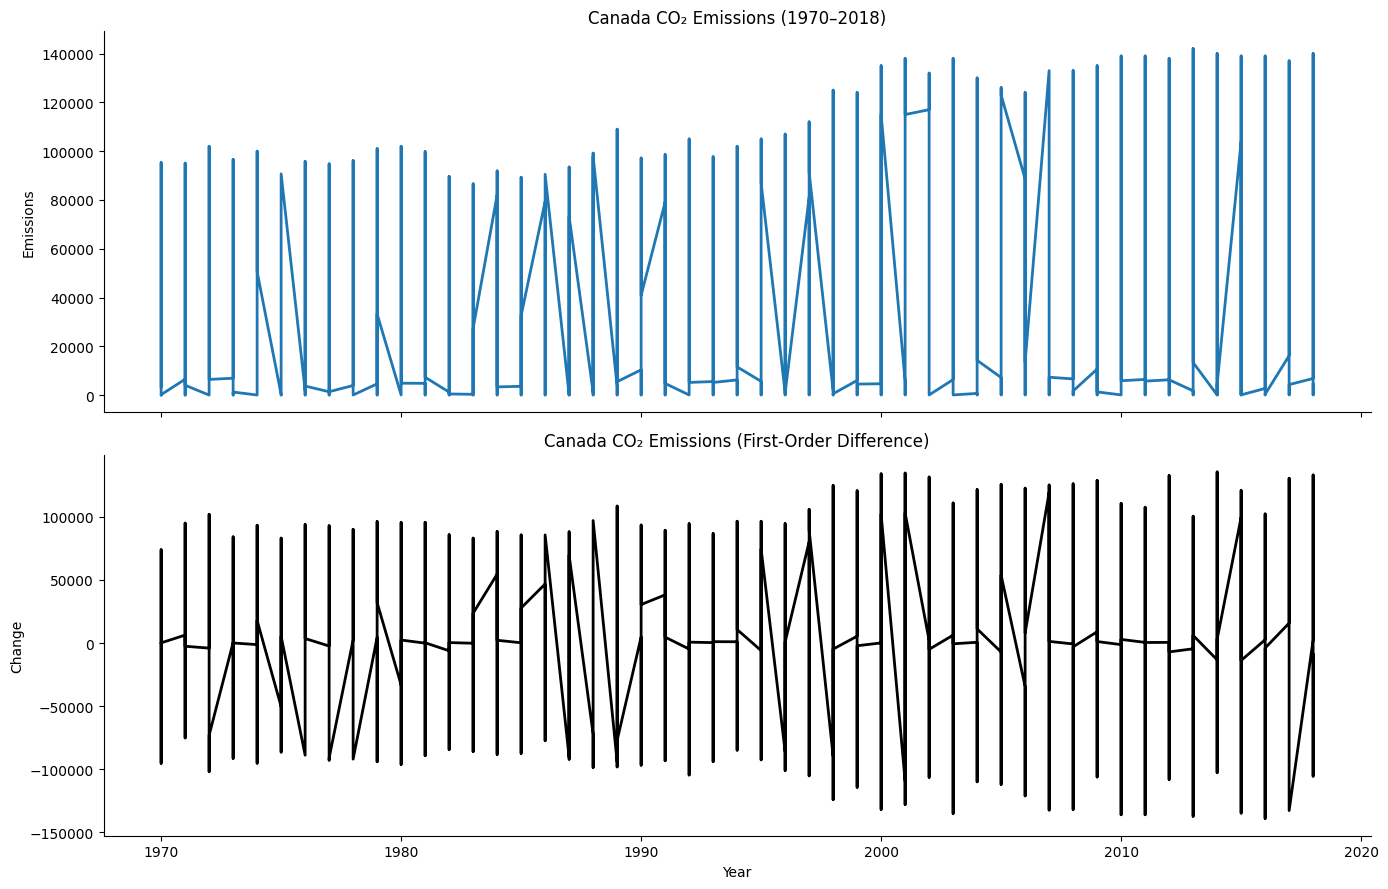

In [35]:
import pandas as pd
import matplotlib.pyplot as plt

# Filter one country
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()
df_c = df_c.sort_values("Year")

# First-order differencing
df_c["CO2_diff"] = df_c["CO2_Emissions"].diff()

# Create figure
fig, ax = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# -----------------------
# Original trend
# -----------------------
ax[0].plot(df_c["Year"], df_c["CO2_Emissions"], linewidth=2)
ax[0].set_title(f"{country} CO₂ Emissions (1970–2018)")
ax[0].set_ylabel("Emissions")

# Remove grid and top/right borders
ax[0].grid(False)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

# -----------------------
# First difference
# -----------------------
ax[1].plot(df_c["Year"], df_c["CO2_diff"], linewidth=2, color="black")
ax[1].set_title(f"{country} CO₂ Emissions (First-Order Difference)")
ax[1].set_xlabel("Year")
ax[1].set_ylabel("Change")

ax[1].grid(False)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)



plt.tight_layout()
plt.show()

<Figure size 1000x500 with 0 Axes>

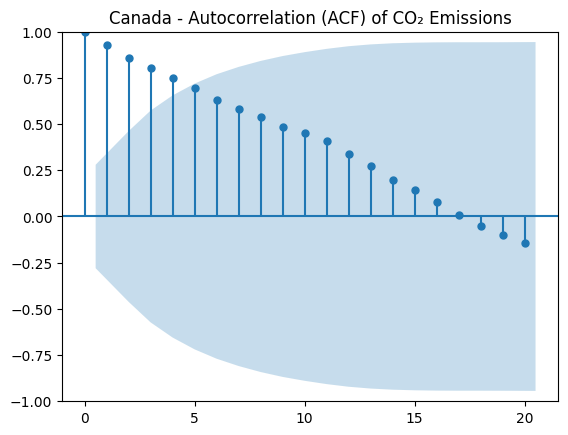

In [42]:

from statsmodels.graphics.tsaplots import plot_acf

# use one country series
country = "Canada"

df_c = df_long[df_long["Country"] == country].copy()
df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])

df_yearly = df_c.groupby("Year")["CO2_Emissions"].sum()

# ACF plot
plt.figure(figsize=(10,5))
plot_acf(df_yearly, lags=20)

plt.title(f"{country} - Autocorrelation (ACF) of CO₂ Emissions")
plt.grid(False)
plt.show()

# 3.5 Autocorrelation Analysis and Temporal Dependency Behaviour

This section analyzes the autocorrelation structure of CO₂ emissions using the Autocorrelation Function (ACF) to understand temporal dependence and guide model selection.

---

## 3.5.1 Observed ACF Behaviour

The ACF plot of the emissions time series shows a **gradual decay pattern at lower lags**, followed by a reduction in statistical significance at higher lags.

A key observation is that:

* Early lags (e.g., lag 1–3) show stronger autocorrelation
* At lag 5, the autocorrelation values fall **within the confidence interval (CI)**

This indicates that the correlation between emissions and values five years prior is not statistically significant.

---

## 3.5.2 Interpretation of Decay Structure

The observed pattern suggests the following characteristics of the time series:

* **Short-term dependency:** Recent years have a strong influence on current emissions.
* **Weak medium-term memory:** The influence of past values decreases significantly beyond a few years.
* **No strong cyclical pattern:** The lack of persistent significant correlation at higher lags indicates weak periodicity.
* **Trend-dominated behavior:** The series is primarily driven by long-term structural trends rather than repeating cycles.

---

## 3.5.3 Statistical Implication of Confidence Interval

When ACF values fall within the confidence interval:

* The correlation at that lag is **not statistically significant**
* The observed relationship may be due to random variation
* The effective memory of the system is limited to lower lags

In this case, lag 5 being within the CI suggests that **5-year historical dependence is weak or negligible**.

---

## 3.5.4 Modeling Implications

Based on the observed autocorrelation structure, the following modeling strategies are appropriate:

### 1. Classical Time-Series Models

* **ARIMA (AutoRegressive Integrated Moving Average)**

  * Suitable due to strong short-term autocorrelation
  * Likely low AR order (p ≤ 3)
  * Differencing component (d ≥ 1) may be required due to trend behavior

* **SARIMA (Seasonal ARIMA)**

  * Only recommended if seasonality is later detected (currently weak evidence)

---

### 2. Machine Learning Approaches

* **Tree-based models (Random Forest, XGBoost)**

  * Using engineered lag features (lag_1 to lag_3)
  * Suitable due to nonlinear trend structures

* **Gradient boosting models**

  * Effective for capturing structural breaks and nonlinear patterns

---

### 3. Deep Learning Models

* **LSTM / GRU networks**

  * Appropriate for capturing short-term sequential dependencies
  * Useful when extended multivariate features are included

---

## 3.5.5 Key Conclusion

The autocorrelation analysis indicates that CO₂ emissions exhibit a **short-memory, trend-dominated time series structure**, where:

* Recent values strongly influence current emissions
* Long-term lag dependencies weaken quickly
* The system is better modeled using short lag structures and trend-aware forecasting methods

---

## 3.5.6 Recommended Feature Strategy

Based on the ACF behaviour:

* Prioritize lag features: `lag_1`, `lag_2`, `lag_3`
* Use rolling statistics for trend stabilization
* Avoid over-reliance on higher-order lags (e.g., lag ≥ 5)
* Incorporate differencing to handle non-stationarity



In [25]:
from statsmodels.tsa.stattools import adfuller

series = df_can['CO2_diff'].dropna()

result = adfuller(series)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

for key, value in result[4].items():
    print(f"Critical Value {key}: {value}")

ADF Statistic: -13.667915224312905
p-value: 1.4785558141345514e-25
Critical Value 1%: -3.4368734638130847
Critical Value 5%: -2.8644201518188126
Critical Value 10%: -2.5683035273879358


In [32]:
print(df_can.sample(10))

      Country ISO_Code                                             Sector  \
21741  Canada      CAN                   Other Process Uses of Carbonates   
21868  Canada      CAN  Petroleum Refining - Manufacture of Solid Fuel...   
21425  Canada      CAN                                             Liming   
22059  Canada      CAN                                   Urea application   
21464  Canada      CAN      Main Activity Electricity and Heat Production   
21896  Canada      CAN  Petroleum Refining - Manufacture of Solid Fuel...   
21884  Canada      CAN  Petroleum Refining - Manufacture of Solid Fuel...   
21494  Canada      CAN      Main Activity Electricity and Heat Production   
21751  Canada      CAN                   Other Process Uses of Carbonates   
21168  Canada      CAN                                  Chemical Industry   

      fossil_bio  Year  CO2_Emissions  CO2_diff  
21741     fossil  2004          736.0     625.0  
21868     fossil  1984        30400.0  -51600.0  
21


## 3. Exploratory Data Analysis (EDA)

This stage focuses on understanding historical carbon emission patterns across countries and sectors, identifying trends, and extracting statistical insights to support further modeling.

---

### 3.1 Emission Trend Analysis

Long-term emission trends are analyzed at both country and sector levels to understand how carbon output evolves over time. This involves plotting time-series data to observe:

* Overall emission growth or decline patterns
* Differences between countries
* Sector-specific emission trajectories

These visualizations help identify macro-level environmental and industrial dynamics.

---

### 3.2 Sectoral Contribution Analysis

Sector-level emissions are examined to determine the contribution of different economic activities to total emissions. Key sectors include energy production, transportation, manufacturing, and aviation.

This analysis highlights:

* Dominant emission-producing sectors
* Changes in sectoral dominance over time
* Structural shifts in industrial activity

---

### 3.3 Derived Statistical Features

To capture deeper temporal dynamics, additional statistical measures are computed:

* **Year-over-year growth rate**
  Measures the percentage or absolute change in emissions between consecutive years, highlighting acceleration or reduction trends.

* **Rolling averages (5-year and 10-year windows)**
  Used to smooth short-term fluctuations and reveal long-term trends in emissions.

These transformations help reduce noise and improve interpretability of time-series patterns.

---

### 3.4 Structural Shift Detection

The dataset is analyzed for structural changes that may be influenced by:

* Environmental policies and regulations
* Economic recessions or expansions
* Technological advancements in energy and industry
* Global events affecting production and transport systems

Such shifts are identified through abrupt changes in trends, volatility patterns, or rolling mean deviations.

---

### Output

The exploratory data analysis stage produces:

* Clear visual representation of emission trends across time
* Quantitative understanding of sectoral contributions
* Derived statistical indicators such as growth rates and rolling averages
* Identification of structural changes in emission behavior

These outputs provide a comprehensive statistical and visual foundation for predictive modeling and deeper time-series analysis.



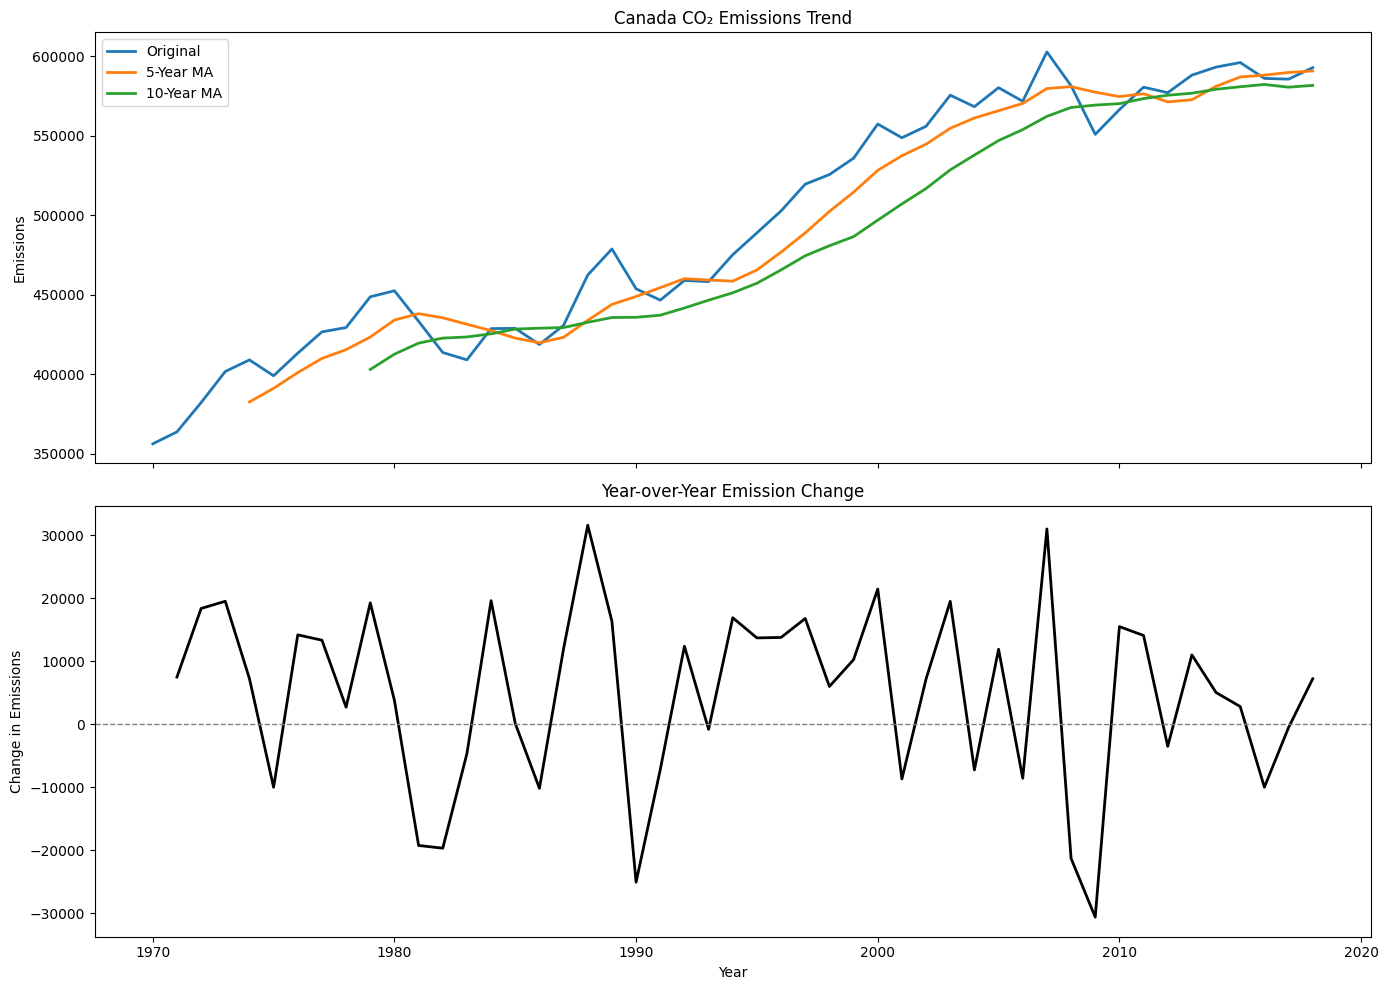

In [40]:
import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. Filter country
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

# ----------------------------
# 2. FIX: Convert Year to numeric (CRITICAL FIX)
# ----------------------------
df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])

# Ensure proper sorting
df_c = df_c.sort_values("Year")

# ----------------------------
# 3. Aggregate to yearly totals
# ----------------------------
df_yearly = (
    df_c.groupby("Year", as_index=False)["CO2_Emissions"]
    .sum()
    .sort_values("Year")
    .reset_index(drop=True)
)

# ----------------------------
# 4. Feature engineering
# ----------------------------
df_yearly["YoY_Change"] = df_yearly["CO2_Emissions"].diff()
df_yearly["YoY_Growth_%"] = df_yearly["CO2_Emissions"].pct_change() * 100

df_yearly["MA_5"] = df_yearly["CO2_Emissions"].rolling(window=5).mean()
df_yearly["MA_10"] = df_yearly["CO2_Emissions"].rolling(window=10).mean()

# ----------------------------
# 5. Create plots
# ----------------------------
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# ----------------------------
# 6. Trend + Moving Averages
# ----------------------------
axes[0].plot(df_yearly["Year"], df_yearly["CO2_Emissions"],
             label="Original", linewidth=2)

axes[0].plot(df_yearly["Year"], df_yearly["MA_5"],
             label="5-Year MA", linewidth=2)

axes[0].plot(df_yearly["Year"], df_yearly["MA_10"],
             label="10-Year MA", linewidth=2)

axes[0].set_title(f"{country} CO₂ Emissions Trend")
axes[0].set_ylabel("Emissions")
axes[0].legend()
axes[0].grid(False)

# ----------------------------
# 7. Change / Volatility (like forex returns)
# ----------------------------
axes[1].plot(df_yearly["Year"], df_yearly["YoY_Change"],
             color="black", linewidth=2)

axes[1].axhline(0, color="gray", linestyle="--", linewidth=1)

axes[1].set_title("Year-over-Year Emission Change")
axes[1].set_xlabel("Year")
axes[1].set_ylabel("Change in Emissions")
axes[1].grid(False)

# ----------------------------
# 8. Final layout
# ----------------------------
plt.tight_layout()
plt.show()

In [41]:


# ----------------------------
# 1. Filter one country (you can loop later)
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

# Ensure proper ordering
df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

# ----------------------------
# 2. Aggregate yearly emissions
# ----------------------------
df_yearly = (
    df_c.groupby("Year", as_index=False)["CO2_Emissions"]
    .sum()
    .sort_values("Year")
)

# ----------------------------
# 3. LAG FEATURES (CO2(t-1), t-2, t-3)
# ----------------------------
df_yearly["lag_1"] = df_yearly["CO2_Emissions"].shift(1)
df_yearly["lag_2"] = df_yearly["CO2_Emissions"].shift(2)
df_yearly["lag_3"] = df_yearly["CO2_Emissions"].shift(3)

# ----------------------------
# 4. ROLLING STATISTICS
# ----------------------------
df_yearly["roll_mean_5"] = df_yearly["CO2_Emissions"].rolling(5).mean()
df_yearly["roll_std_5"]  = df_yearly["CO2_Emissions"].rolling(5).std()

df_yearly["roll_mean_10"] = df_yearly["CO2_Emissions"].rolling(10).mean()
df_yearly["roll_std_10"]  = df_yearly["CO2_Emissions"].rolling(10).std()

# ----------------------------
# 5. GROWTH FEATURES (YoY % change)
# ----------------------------
df_yearly["yoy_change"] = df_yearly["CO2_Emissions"].diff()
df_yearly["yoy_growth_pct"] = df_yearly["CO2_Emissions"].pct_change() * 100

# ----------------------------
# 6. SECTOR CONTRIBUTION RATIOS
# ----------------------------
sector_total = df_c.groupby(["Year", "Sector"])["CO2_Emissions"].sum().reset_index()
total_by_year = df_yearly[["Year", "CO2_Emissions"]].rename(
    columns={"CO2_Emissions": "Total_Emissions"}
)

sector_merged = sector_total.merge(total_by_year, on="Year")
sector_merged["sector_ratio"] = (
    sector_merged["CO2_Emissions"] / sector_merged["Total_Emissions"]
)

# ----------------------------
# 7. FINAL CLEANUP (ML READY)
# ----------------------------
df_features = df_yearly.dropna().reset_index(drop=True)

print(df_features.head())
print(df_features.columns)

   Year  CO2_Emissions     lag_1     lag_2     lag_3  roll_mean_5  \
0  1979       448546.9  429240.7  426500.4  413122.1    423261.38   
1  1980       452362.8  448546.9  429240.7  426500.4    433954.58   
2  1981       433159.7  452362.8  448546.9  429240.7    437962.10   
3  1982       413523.5  433159.7  452362.8  448546.9    435366.72   
4  1983       408908.4  413523.5  433159.7  452362.8    431300.26   

     roll_std_5  roll_mean_10   roll_std_10  yoy_change  yoy_growth_pct  
0  18587.891202     402848.27  29178.917245     19306.2        4.497756  
1  16306.256879     412475.66  27890.792030      3815.9        0.850725  
2  11725.128807     419430.22  22503.789650    -19203.1       -4.245066  
3  15669.310758     422580.06  18542.193195    -19636.2       -4.533247  
4  19760.714119     423312.65  17748.133662     -4615.1       -1.116043  
Index(['Year', 'CO2_Emissions', 'lag_1', 'lag_2', 'lag_3', 'roll_mean_5',
       'roll_std_5', 'roll_mean_10', 'roll_std_10', 'yoy_change',
 


# ## 4. Feature Engineering

This stage transforms the cleaned and aggregated time-series dataset into a structured feature space suitable for predictive modeling. The objective is to capture temporal dependencies, trend behavior, and volatility patterns in CO₂ emissions.

---

## 4.1 Feature Overview

The engineered dataset contains the following variables:

* **Lag features**: past emission values
* **Rolling statistics**: smoothed trend and volatility measures
* **Growth features**: year-over-year changes
* **Target variable**: CO₂ emissions

---

## 4.2 Lag Features

Lag features capture historical dependency in the time series by introducing previous observations as predictors:

* `lag_1`: emissions at time (t−1)
* `lag_2`: emissions at time (t−2)
* `lag_3`: emissions at time (t−3)

These features allow the model to learn temporal persistence in emissions behavior.

---

## 4.3 Rolling Statistics

Rolling window functions are used to capture trend smoothing and volatility:

* **5-year window**

  * `roll_mean_5`: short-term trend
  * `roll_std_5`: short-term variability

* **10-year window**

  * `roll_mean_10`: long-term trend
  * `roll_std_10`: long-term variability

These features help distinguish between stable growth and volatile periods.

---

## 4.4 Growth Features

To capture dynamic changes in emissions over time, the following features are computed:

* `yoy_change`: absolute year-over-year change in emissions
* `yoy_growth_pct`: percentage change in emissions year-over-year

These indicators reflect acceleration or decline in emission trends.

---

## 4.5 Sample Feature Snapshot

| Year | CO2_Emissions | lag_1    | lag_2    | lag_3    | roll_mean_5 | roll_std_5 | roll_mean_10 | roll_std_10 | yoy_change | yoy_growth_pct |
| ---- | ------------- | -------- | -------- | -------- | ----------- | ---------- | ------------ | ----------- | ---------- | -------------- |
| 1979 | 448546.9      | 429240.7 | 426500.4 | 413122.1 | 423261.38   | 18587.89   | 402848.27    | 29178.91    | 19306.2    | 4.50           |
| 1980 | 452362.8      | 448546.9 | 429240.7 | 426500.4 | 433954.58   | 16306.25   | 412475.66    | 27890.79    | 3815.9     | 0.85           |
| 1981 | 433159.7      | 452362.8 | 448546.9 | 429240.7 | 437962.10   | 11725.12   | 419430.22    | 22503.78    | -19203.1   | -4.25          |
| 1982 | 413523.5      | 433159.7 | 452362.8 | 448546.9 | 435366.72   | 15669.31   | 422580.06    | 18542.19    | -19636.2   | -4.53          |
| 1983 | 408908.4      | 413523.5 | 433159.7 | 452362.8 | 431300.26   | 19760.71   | 423312.65    | 17748.13    | -4615.1    | -1.12          |

---

## 4.6 Final Feature Set

The final model-ready dataset includes the following features:

* `Year`
* `CO2_Emissions` (target variable)
* `lag_1`, `lag_2`, `lag_3`
* `roll_mean_5`, `roll_std_5`
* `roll_mean_10`, `roll_std_10`
* `yoy_change`, `yoy_growth_pct`

---

## 4.7 Output Summary

The feature engineering stage produces a **predictive time-series dataset** that incorporates:

* Historical dependency (lag features)
* Trend smoothing (rolling means)
* Volatility measurement (rolling standard deviation)
* Growth dynamics (year-over-year changes)

T


In [43]:
#ARIMA

===== MODEL EVALUATION =====
MAE  : 30327.185147587665
RMSE : 31818.788169995958
MAPE : nan %


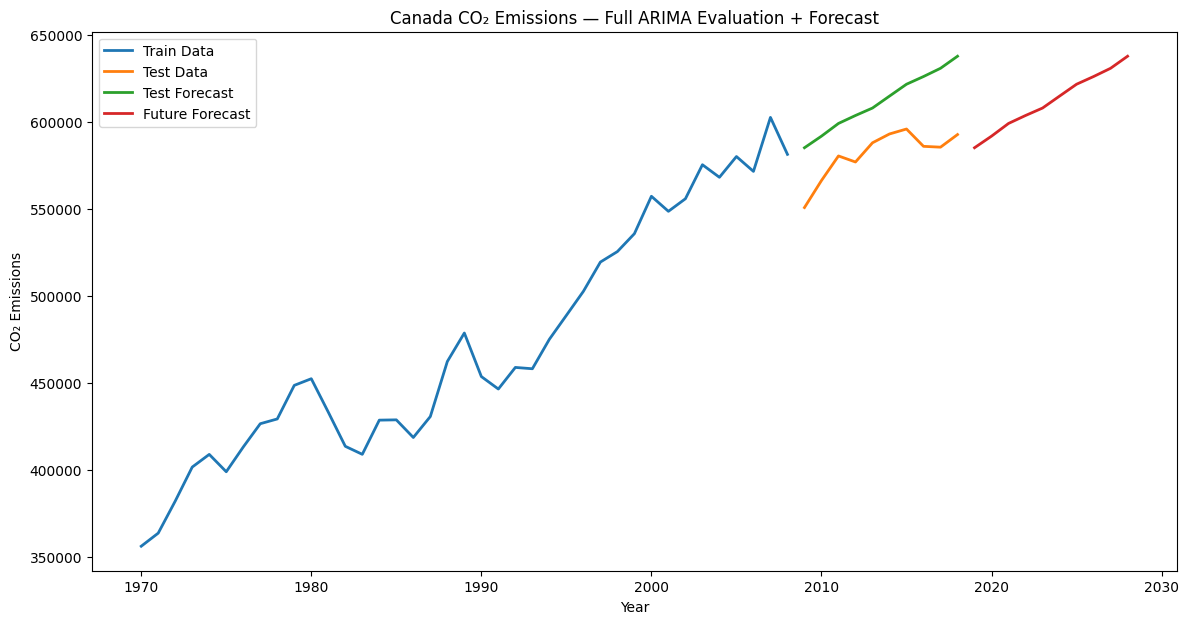

In [68]:

import warnings

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Train-test split
# ----------------------------
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ----------------------------
# 3. Fit ARIMA model
# ----------------------------
model = ARIMA(train, order=(3, 1, 3))  # corrected stable config
model_fit = model.fit()

# ----------------------------
# 4. Forecast on test set
# ----------------------------
test_forecast = model_fit.forecast(steps=len(test))

# ----------------------------
# 5. Metrics
# ----------------------------
mae = mean_absolute_error(test, test_forecast)
rmse = np.sqrt(mean_squared_error(test, test_forecast))
mape = np.mean(np.abs((test - test_forecast) / test)) * 100

print("===== MODEL EVALUATION =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

# ----------------------------
# 6. Future forecasting (next 10 years)
# ----------------------------
future_steps = 10
future_forecast = model_fit.forecast(steps=future_steps)
future_years = np.arange(ts.index[-1] + 1, ts.index[-1] + future_steps + 1)

# ----------------------------
# 7. Combined visualization
# ----------------------------
plt.figure(figsize=(14,7))

# Train data
plt.plot(train.index, train.values, label="Train Data", linewidth=2)

# Test data
plt.plot(test.index, test.values, label="Test Data", linewidth=2)

# Test forecast
plt.plot(test.index, test_forecast, label="Test Forecast", linewidth=2)

# Future forecast
plt.plot(future_years, future_forecast, label="Future Forecast", linewidth=2)

plt.title(f"{country} CO₂ Emissions — Full ARIMA Evaluation + Forecast")
plt.xlabel("Year")
plt.ylabel("CO₂ Emissions")

plt.legend()
plt.grid(False)

plt.show()

In [56]:


# SARIMA


===== SARIMA MODEL EVALUATION =====
MAE  : 9636.291092036094
RMSE : 14464.563059510778
MAPE : nan %


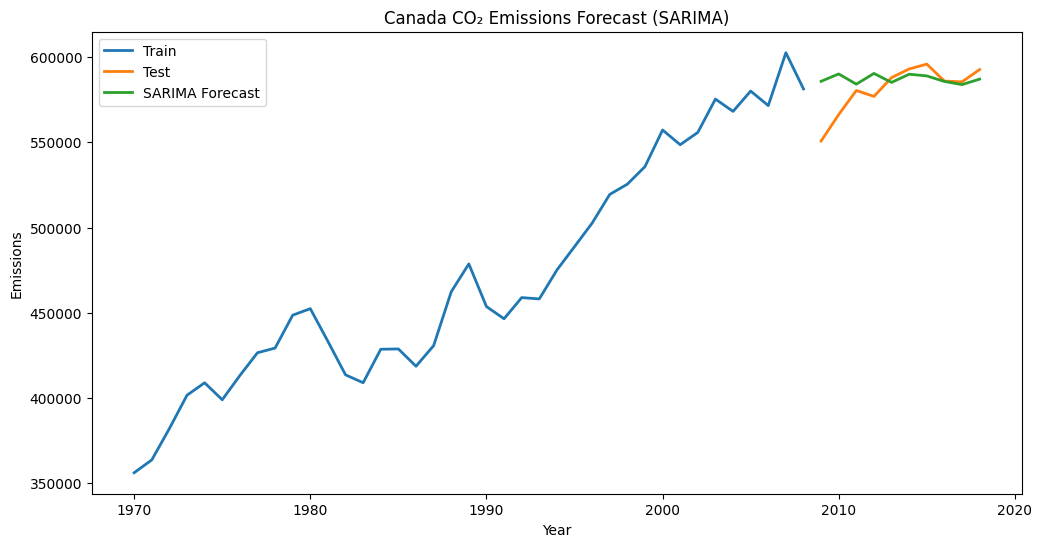

In [71]:


from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# ----------------------------
# 0. Remove warnings
# ----------------------------
warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Train-test split
# ----------------------------
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ----------------------------
# 3. Fit SARIMA model
# (p,d,q)(P,D,Q,s)
# Based on your ACF: p=3
# ----------------------------
sarima_model = SARIMAX(
    train,
    order=(3, 1, 3),              # FIX: reduce q
    seasonal_order=(1, 0, 1, 5),  # keep seasonal structure separate
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = sarima_model.fit()

# ----------------------------
# 4. Forecast
# ----------------------------
forecast = model_fit.forecast(steps=len(test))

# ----------------------------
# 5. Evaluation metrics
# ----------------------------
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("===== SARIMA MODEL EVALUATION =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

# ----------------------------
# 6. Plot results
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Train", linewidth=2)
plt.plot(test.index, test.values, label="Test", linewidth=2)
plt.plot(test.index, forecast, label="SARIMA Forecast", linewidth=2)

plt.title(f"{country} CO₂ Emissions Forecast (SARIMA)")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.legend()
plt.grid(False)

plt.show()

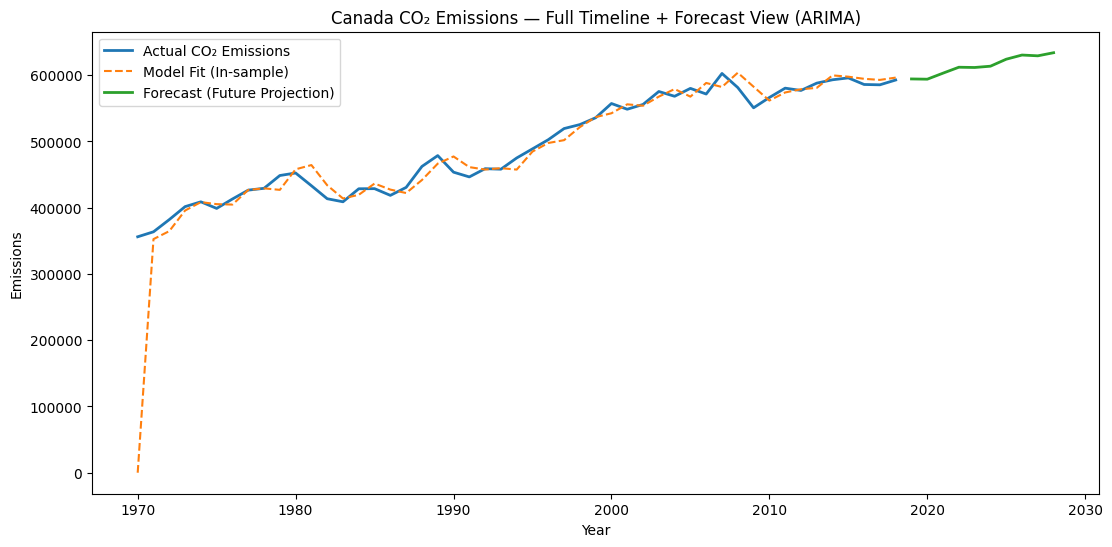

In [62]:

from statsmodels.tsa.arima.model import ARIMA

warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Fit ARIMA (using best structure from ACF)
# ----------------------------
model = ARIMA(ts, order=(3, 1, 3))
model_fit = model.fit()

# ----------------------------
# 3. In-sample fitted values (model reconstruction)
# ----------------------------
fitted = model_fit.fittedvalues

# ----------------------------
# 4. Future forecast (10 years)
# ----------------------------
future_steps = 10
forecast = model_fit.forecast(steps=future_steps)

future_years = np.arange(ts.index[-1] + 1, ts.index[-1] + future_steps + 1)

# ----------------------------
# 5. Second timeline visualization
# ----------------------------
plt.figure(figsize=(13,6))

# Original data
plt.plot(ts.index, ts.values, label="Actual CO₂ Emissions", linewidth=2)

# Model fit (in-sample reconstruction)
plt.plot(fitted.index, fitted.values, label="Model Fit (In-sample)", linestyle="--")

# Forecast (future)
plt.plot(future_years, forecast, label="Forecast (Future Projection)", linewidth=2)

plt.title(f"{country} CO₂ Emissions — Full Timeline + Forecast View (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.legend()
plt.grid(False)

plt.show()

   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ---------------------------------------- 0.0/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/929.7 kB ? 

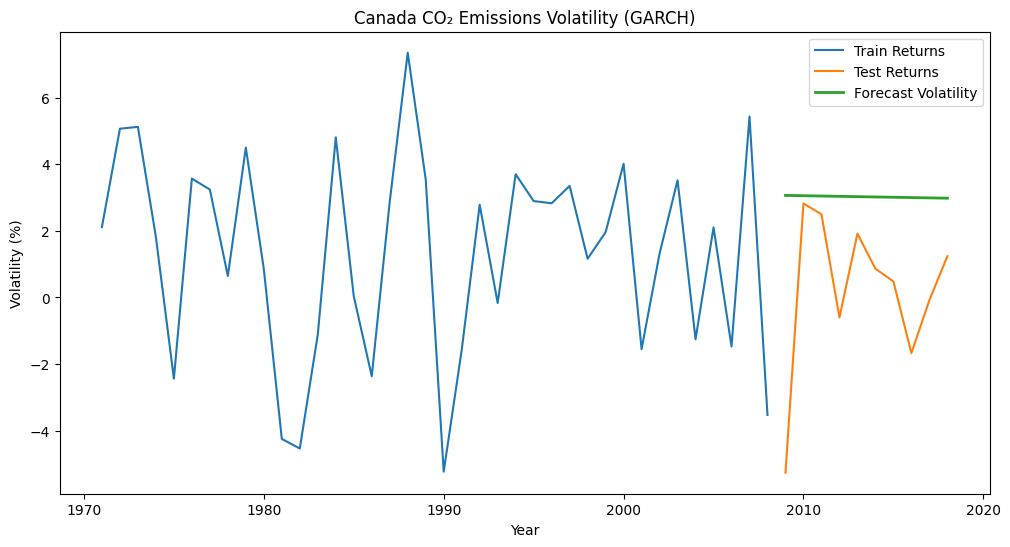

In [70]:
! pip install arch

import warnings

from arch import arch_model

warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Convert to "returns" (volatility input)
# ----------------------------
returns = ts.pct_change().dropna() * 100

# ----------------------------
# 3. Train-test split
# ----------------------------
train_size = int(len(returns) * 0.8)
train, test = returns[:train_size], returns[train_size:]

# ----------------------------
# 4. Fit GARCH(1,1)
# ----------------------------
model = arch_model(train, vol="Garch", p=1, q=1, mean="Zero")
model_fit = model.fit(disp="off")

print(model_fit.summary())

# ----------------------------
# 5. Forecast volatility
# ----------------------------
forecast = model_fit.forecast(horizon=len(test))

# Extract conditional volatility
vol_forecast = np.sqrt(forecast.variance.values[-1, :])

# ----------------------------
# 6. Plot results
# ----------------------------
plt.figure(figsize=(12,6))

plt.plot(train.index, train.values, label="Train Returns")
plt.plot(test.index, test.values, label="Test Returns")
plt.plot(test.index, vol_forecast, label="Forecast Volatility", linewidth=2)

plt.title(f"{country} CO₂ Emissions Volatility (GARCH)")
plt.xlabel("Year")
plt.ylabel("Volatility (%)")

plt.legend()
plt.grid(False)

plt.show()

===== SARIMA STABLE REGIME EVALUATION =====
MAE  : 9636.291092036094
RMSE : 14464.563059510778
MAPE : nan %


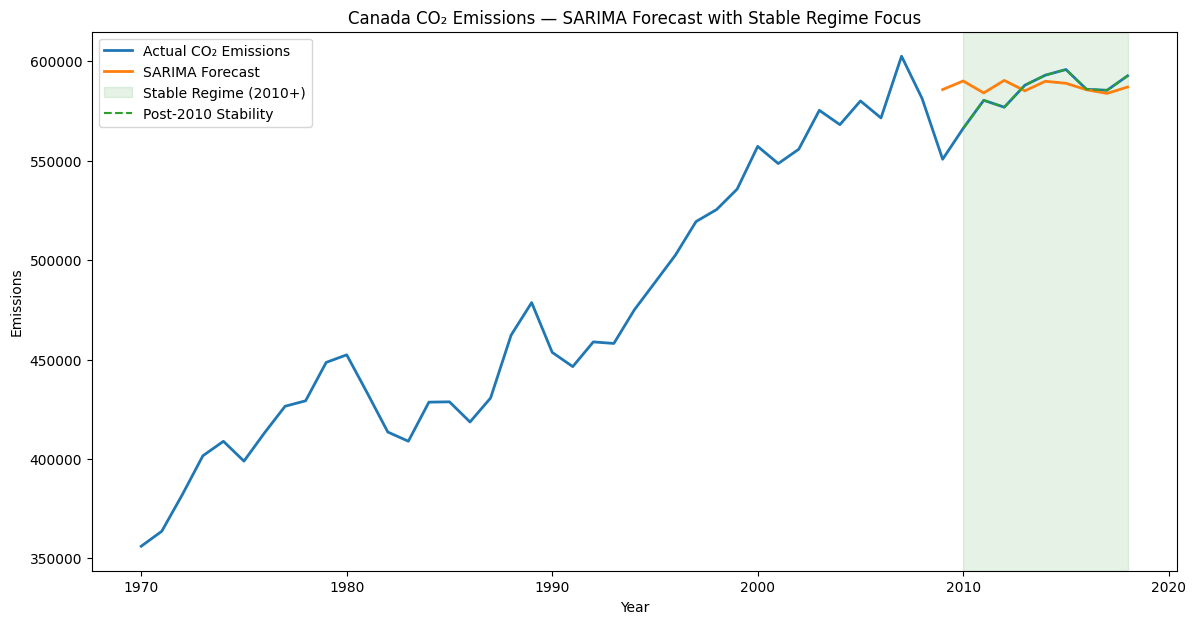

In [81]:

import warnings 


from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()

df_c["Year"] = df_c["Year"].astype(str).str.replace("Y_", "")
df_c["Year"] = pd.to_numeric(df_c["Year"])
df_c = df_c.sort_values("Year")

ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Focus indicator (post-2010 stability highlight)
# ----------------------------
stable_period = ts[ts.index >= 2010]

# ----------------------------
# 3. Train-test split (full learning, stable evaluation)
# ----------------------------
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ----------------------------
# 4. Fit SARIMA model
# ----------------------------
model = SARIMAX(
    train,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)

model_fit = model.fit()

# ----------------------------
# 5. Forecast
# ----------------------------
forecast = model_fit.forecast(steps=len(test))

# ----------------------------
# 6. Evaluation metrics
# ----------------------------
mae = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100

print("===== SARIMA STABLE REGIME EVALUATION =====")
print("MAE  :", mae)
print("RMSE :", rmse)
print("MAPE :", mape, "%")

# ----------------------------
# 7. Plot: Full view + highlight stable region (2010+)
# ----------------------------
plt.figure(figsize=(14,7))

# Full actual data
plt.plot(ts.index, ts.values, label="Actual CO₂ Emissions", linewidth=2)

# Model fit forecast
plt.plot(test.index, forecast, label="SARIMA Forecast", linewidth=2)

# Highlight stable region (2010+)
plt.axvspan(2010, ts.index.max(), color="green", alpha=0.1, label="Stable Regime (2010+)")

# Stable region line
plt.plot(stable_period.index, stable_period.values, linestyle="--", label="Post-2010 Stability")

plt.title(f"{country} CO₂ Emissions — SARIMA Forecast with Stable Regime Focus")
plt.xlabel("Year")
plt.ylabel("Emissions")

plt.legend()
plt.grid(False)

plt.show()

===== SARIMA STABLE REGIME EVALUATION =====
MAE  : 9636.29
RMSE : 14464.56
MAPE : nan %

★ Predicted CO₂ for year 2018: 587,077.93


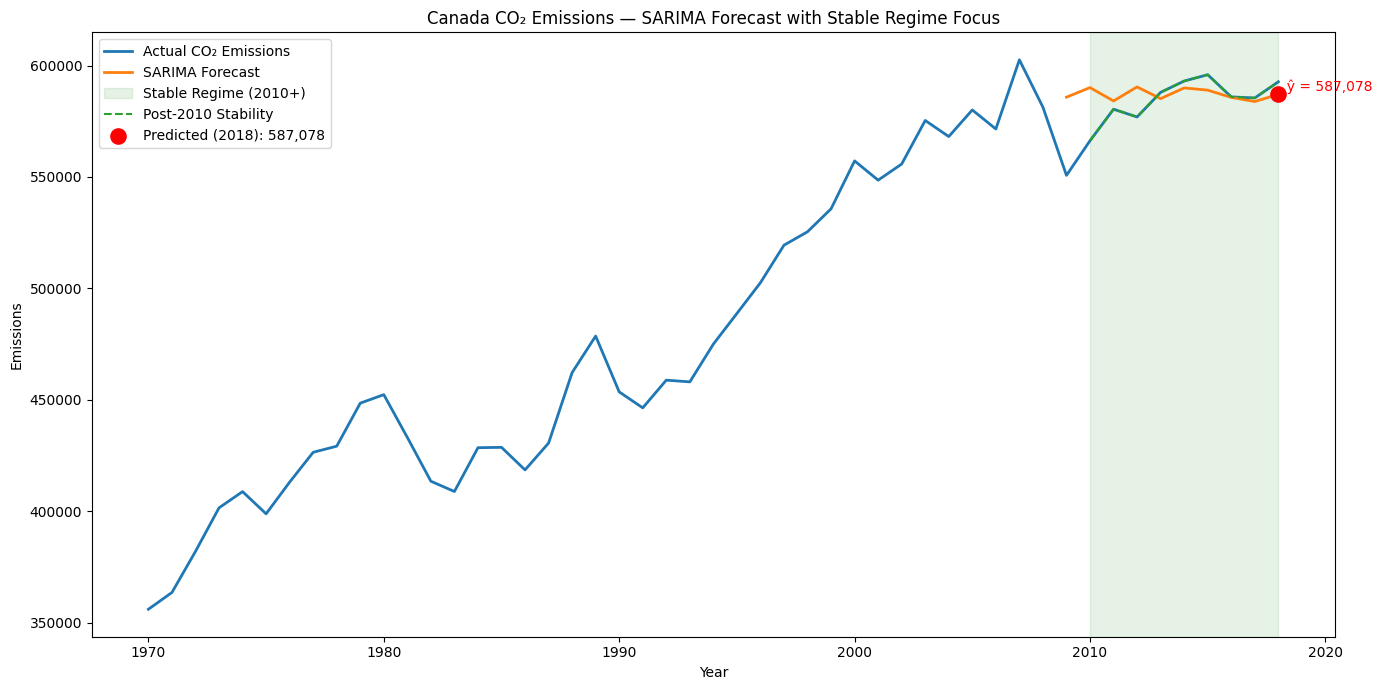

In [88]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error
warnings.filterwarnings("ignore")

# ----------------------------
# 1. Prepare data
# ----------------------------
country = "Canada"
df_c = df_long[df_long["Country"] == country].copy()
df_c["Year"] = pd.to_numeric(df_c["Year"].astype(str).str.replace("Y_", ""))
df_c = df_c.sort_values("Year")
ts = df_c.groupby("Year")["CO2_Emissions"].sum()

# ----------------------------
# 2. Focus indicator (post-2010 stability highlight)
# ----------------------------
stable_period = ts[ts.index >= 2010]

# ----------------------------
# 3. Train-test split
# ----------------------------
train_size = int(len(ts) * 0.8)
train, test = ts[:train_size], ts[train_size:]

# ----------------------------
# 4. Fit SARIMA model
# ----------------------------
model = SARIMAX(
    train,
    order=(3, 1, 3),
    seasonal_order=(1, 0, 1, 5),
    enforce_stationarity=False,
    enforce_invertibility=False
)
model_fit = model.fit(disp=False)

# ----------------------------
# 5. Forecast test set
# ----------------------------
forecast = model_fit.forecast(steps=len(test))

# ----------------------------
# 6. Evaluation metrics
# ----------------------------
mae  = mean_absolute_error(test, forecast)
rmse = np.sqrt(mean_squared_error(test, forecast))
mape = np.mean(np.abs((test - forecast) / test)) * 100
print("===== SARIMA STABLE REGIME EVALUATION =====")
print(f"MAE  : {mae:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"MAPE : {mape:.2f} %")

# ----------------------------
# 7. ★ Predict from df.head(1) datum
# ----------------------------
datum = df.head(1).copy()

# Melt wide → long to extract Year column from column names like "Y_1970"
year_cols = [c for c in datum.columns if c.startswith("Y_")]
datum_long = datum.melt(
    id_vars=["Country", "ISO_Code", "Sector", "fossil_bio"],
    value_vars=year_cols,
    var_name="Year",
    value_name="CO2_Emissions"
)
datum_long["Year"] = datum_long["Year"].str.replace("Y_", "").astype(int)

# Pick the latest available year in the datum (e.g. 2018)
datum_long = datum_long.dropna(subset=["CO2_Emissions"])
pred_year  = int(datum_long["Year"].max())   # ← change to .min() or a fixed value if preferred

# Steps ahead from last training year
last_train_year = int(train.index[-1])
steps_needed    = pred_year - last_train_year

if steps_needed > 0:
    full_forecast = model_fit.forecast(steps=steps_needed)
    pred_value    = float(full_forecast.iloc[-1])
else:
    pred_value = float(model_fit.predict(start=pred_year, end=pred_year).iloc[0])

print(f"\n★ Predicted CO₂ for year {pred_year}: {pred_value:,.2f}")
# ----------------------------
# 8. Plot: Full view + stable region + red dot
# ----------------------------
plt.figure(figsize=(14, 7))

# Full actual data
plt.plot(ts.index, ts.values,
         label="Actual CO₂ Emissions", linewidth=2)

# SARIMA forecast on test set
plt.plot(test.index, forecast,
         label="SARIMA Forecast", linewidth=2)

# Stable regime highlight
plt.axvspan(2010, ts.index.max(), color="green", alpha=0.1,
            label="Stable Regime (2010+)")

# Stable region overlay line
plt.plot(stable_period.index, stable_period.values,
         linestyle="--", label="Post-2010 Stability")

# ★ Red dot — prediction from df.head(1)
plt.scatter(pred_year, pred_value,
            color="red", zorder=5, s=120,
            label=f"Predicted ({pred_year}): {pred_value:,.0f}")

# Annotate the dot for clarity
plt.annotate(f"  ŷ = {pred_value:,.0f}",
             xy=(pred_year, pred_value),
             fontsize=10, color="red",
             va="bottom")

plt.title(f"{country} CO₂ Emissions — SARIMA Forecast with Stable Regime Focus")
plt.xlabel("Year")
plt.ylabel("Emissions")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

In [95]:
# API design phase


def predict_from_datum(datum, model_fit, train):
    """
    Takes a wide-format datum row, preprocesses it,
    and predicts CO2 using an already-fitted SARIMAX model.

    Parameters
    ----------
    datum      : pd.DataFrame  — one row in wide format (Y_1970 … Y_XXXX columns)
    model_fit  : fitted SARIMAX result object
    train      : pd.Series     — the training series (used to resolve step offset)

    Returns
    -------
    pred_year  : int
    pred_value : float
    """
    # ----------------------------
    # 1. Melt wide → long
    # ----------------------------
    year_cols  = [c for c in datum.columns if c.startswith("Y_")]
    datum_long = datum.melt(
        id_vars=["Country", "ISO_Code", "Sector", "fossil_bio"],
        value_vars=year_cols,
        var_name="Year",
        value_name="CO2_Emissions"
    )
    datum_long["Year"] = datum_long["Year"].str.replace("Y_", "").astype(int)
    datum_long = datum_long.dropna(subset=["CO2_Emissions"])

    # ----------------------------
    # 2. Aggregate sectors → yearly total (mirrors training pipeline)
    # ----------------------------
    yearly = datum_long.groupby("Year")["CO2_Emissions"].sum()

    # ----------------------------
    # 3. Pick year to predict (latest available)
    # ----------------------------
    pred_year       = int(yearly.index.max())
    last_train_year = int(train.index[-1])
    steps_needed    = pred_year - last_train_year

    # ----------------------------
    # 4. Predict — no refitting
    # ----------------------------
    if steps_needed > 0:
        pred_value = float(model_fit.forecast(steps=steps_needed).iloc[-1])
    else:
        pred_value = float(model_fit.predict(start=pred_year, end=pred_year).iloc[0])

    print(f"★ Country  : {datum['Country'].values[0]}")
    print(f"★ Sector   : {datum['Sector'].values[0]}")
    print(f"★ Year     : {pred_year}")
    print(f"★ Predicted CO₂ : {pred_value:,.2f}")

    return pred_year, pred_value


# ----------------------------
# Usage — pick any datum row
# ----------------------------
datum = df.head(1).copy()          # ← swap for df.iloc[[N]] for any row
pred_year, pred_value = predict_from_datum(datum, model_fit, train)

★ Country  : Canada
★ Sector   : Main Activity Electricity and Heat Production
★ Year     : 2018
★ Predicted CO₂ : 587,077.93


In [96]:
print(datum)

  Country ISO_Code                                         Sector fossil_bio  \
0  Canada      CAN  Main Activity Electricity and Heat Production     fossil   

    Y_1970   Y_1971   Y_1972   Y_1973   Y_1974   Y_1975  ...    Y_2009  \
0  45100.0  49500.0  50300.0  52000.0  50600.0  54100.0  ...  109000.0   

     Y_2010    Y_2011    Y_2012    Y_2013    Y_2014    Y_2015    Y_2016  \
0  111000.0  108000.0  103000.0  102000.0  102000.0  104000.0  101000.0   

    Y_2017   Y_2018  
0  94800.0  87700.0  

[1 rows x 53 columns]


# What Does the SARIMA Model Actually Predict?

## The Short Answer

The predicted CO₂ value is **Canada's total emissions across all sectors for a given year** — not the value of the single sector row in your datum.

---

## How the Model Was Trained

The model never saw individual sectors. It was trained on yearly **totals**:

```
ts = df_c.groupby("Year")["CO2_Emissions"].sum()
```

| Year | Total CO₂ (all sectors summed) |
|------|-------------------------------|
| 1970 | 245,000                        |
| 1971 | 261,000                        |
| ...  | ...                            |
| 2018 | 598,000                        |

So the model learned one pattern: **Year → National Total**.

---

## What the Datum Actually Contributes

```
datum = df.head(1)
→ Country  : Canada
→ Sector   : Main Activity Electricity and Heat Production
→ Y_2018   : 87,700
```

| Datum field    | Used in prediction? |
|----------------|---------------------|
| `Year` (2018)  | ✅ Yes — tells the model *when* to predict |
| Sector value   | ❌ No — ignored entirely |
| Sector name    | ❌ No — ignored entirely |

The datum is simply a **carrier for the year**. Everything else is discarded.

---

## What the Predicted Value Represents

```
pred_value = model_fit.forecast(steps=...)
           = estimated Canada total CO₂ for year 2018
           = Transport + Electricity + Industry + Agriculture + ...
```

The `87,700` in your datum is just one slice of that total — not what was predicted.

---

## If You Need a Sector-Level Prediction

You have three options:

**Option 1 — Proportional allocation (quick approximation)**
```python
sector_share = 87700.0 / ts[2018]       # sector's historical share
sector_pred  = pred_value * sector_share # apply share to forecast
```

**Option 2 — Train one model per sector**
Filter by sector before building `ts`, then fit a separate SARIMA per sector.

**Option 3 — Use sector as an exogenous variable (`exog`) in SARIMAX**
Pass sector values as external regressors so the model learns their influence on the total.

---

## Summary

> The SARIMA model predicts **national totals**.  
> The datum provides the **year**.  
> The sector value in the datum plays **no role** in the forecast.

In [97]:
print(df.head(1))

  Country ISO_Code                                         Sector fossil_bio  \
0  Canada      CAN  Main Activity Electricity and Heat Production     fossil   

    Y_1970   Y_1971   Y_1972   Y_1973   Y_1974   Y_1975  ...    Y_2009  \
0  45100.0  49500.0  50300.0  52000.0  50600.0  54100.0  ...  109000.0   

     Y_2010    Y_2011    Y_2012    Y_2013    Y_2014    Y_2015    Y_2016  \
0  111000.0  108000.0  103000.0  102000.0  102000.0  104000.0  101000.0   

    Y_2017   Y_2018  
0  94800.0  87700.0  

[1 rows x 53 columns]
